<a href="https://colab.research.google.com/github/Momoru2002/retinal-oct-classification/blob/main/Perbandingan_Kinerja_ResNet50%2C_EfficientNetV2%2C_dan_DenseNet121_untuk_Klasifikasi_Penyakit_Retina_pada_Citra_Optical_Coherence_Tomography_Menggunakan_Explainable_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Muhammad Almas Albirra Hamid**
# **230401193**
## ***Perbandingan Kinerja ResNet50, EfficientNetV2, dan DenseNet121 untuk Klasifikasi Penyakit Retina pada Citra Optical Coherence Tomography Menggunakan Explainable AI***

In [4]:
!pip install kaggle -q

In [5]:
!kaggle datasets download -d obulisainaren/retinal-oct-c8

Dataset URL: https://www.kaggle.com/datasets/obulisainaren/retinal-oct-c8
License(s): CC-BY-NC-SA-4.0
retinal-oct-c8.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
!unzip -o retinal-oct-c8.zip

Streaming output truncated to the last 5000 lines.
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1101.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1102.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1103.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1104.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1105.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1106.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1107.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1108.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1109.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/normal_train_1110.jpg  
  inflating: RetinalOCT_Dataset/RetinalOCT_Dataset/train/NORMAL/norma

In [7]:
import os

for item in os.listdir('/content'):
    print(item)

.config
RetinalOCT_Dataset
retinal-oct-c8.zip
README.md
sample_data


In [8]:
!find /content/RetinalOCT_Dataset -maxdepth 2 -type d

/content/RetinalOCT_Dataset
/content/RetinalOCT_Dataset/RetinalOCT_Dataset
/content/RetinalOCT_Dataset/RetinalOCT_Dataset/val
/content/RetinalOCT_Dataset/RetinalOCT_Dataset/train
/content/RetinalOCT_Dataset/RetinalOCT_Dataset/test


In [9]:
import tensorflow as tf

DATASET_PATH = "/content/RetinalOCT_Dataset/RetinalOCT_Dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/train",
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/val",
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 18400 files belonging to 8 classes.
Found 2800 files belonging to 8 classes.
Found 2800 files belonging to 8 classes.


In [10]:
class_names = train_ds.class_names

print("Jumlah kelas:", len(class_names))
print(class_names)

Jumlah kelas: 8
['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


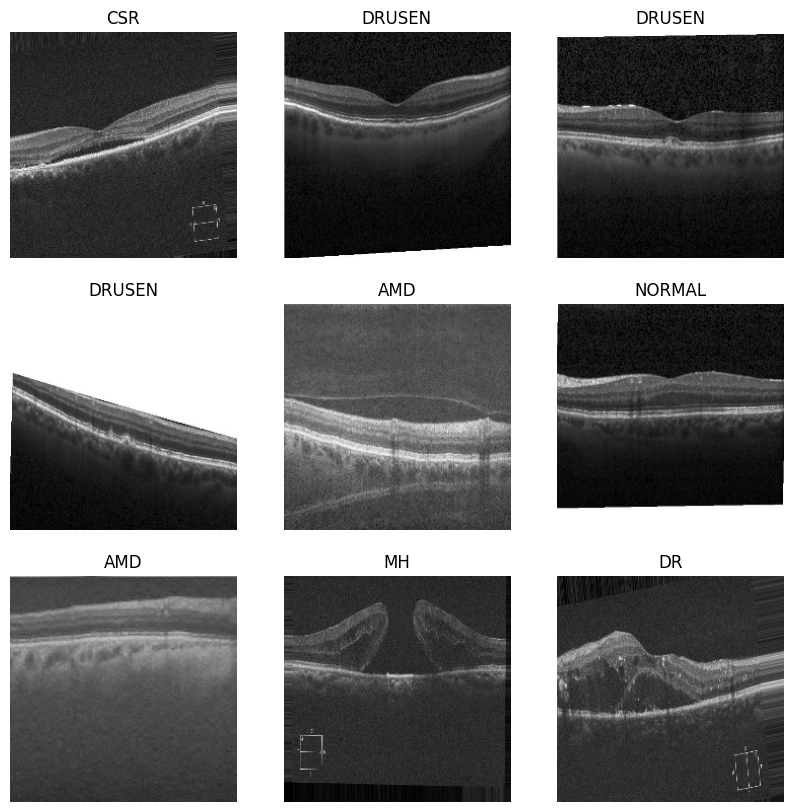

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[int(labels[i])])

        plt.axis("off")

plt.show()

In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model
import tensorflow as tf

In [13]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
inputs = tf.keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

outputs = layers.Dense(
    8,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │      2,056 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )

]

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7976 - loss: 0.5335 - val_accuracy: 0.8007 - val_loss: 0.4877 - learning_rate: 0.0010
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 66s 114ms/step - accuracy: 0.8562 - loss: 0.3728 - val_accuracy: 0.8654 - val_loss: 0.3377 - learning_rate: 0.0010
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 66s 115ms/step - accuracy: 0.8734 - loss: 0.3289 - val_accuracy: 0.8750 - val_loss: 0.3323 - learning_rate: 0.0010
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 65s 112ms/step - accuracy: 0.8805 - loss: 0.3109 - val_accuracy: 0.8857 - val_loss: 0.2993 - learning_rate: 0.0010
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 65s 112ms/step - accuracy: 0.8868 - loss: 0.2920 - val_accuracy: 0.8911 - val_loss: 0.2812 - learning_rate: 0.0010


In [19]:
loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.8939 - loss: 0.2731
Test Accuracy: 0.893928587436676


In [20]:
model.save("resnet50_retina.keras")

In [21]:
base_model.trainable = False

In [22]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 137s 186ms/step - accuracy: 0.8836 - loss: 0.3166 - val_accuracy: 0.9179 - val_loss: 0.2206 - learning_rate: 1.0000e-05
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 101s 176ms/step - accuracy: 0.9416 - loss: 0.1594 - val_accuracy: 0.9282 - val_loss: 0.2039 - learning_rate: 1.0000e-05
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 99s 172ms/step - accuracy: 0.9626 - loss: 0.1045 - val_accuracy: 0.9354 - val_loss: 0.1855 - learning_rate: 1.0000e-05
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 101s 175ms/step - accuracy: 0.9801 - loss: 0.0603 - val_accuracy: 0.9379 - val_loss: 0.2010 - learning_rate: 1.0000e-05
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - accuracy: 0.9870 - loss: 0.0391 - val_accuracy: 0.9389 - val_loss: 0.2135 - learning_rate: 1.0000e-05


In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np

In [26]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(images, verbose=0)

    y_pred.extend(
        np.argmax(preds, axis=1)
    )

    y_true.extend(
        labels.numpy()
    )

In [27]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.88      0.90      0.89       350
         CSR       1.00      1.00      1.00       350
         DME       0.90      0.93      0.91       350
          DR       1.00      1.00      1.00       350
      DRUSEN       0.90      0.77      0.83       350
          MH       1.00      1.00      1.00       350
      NORMAL       0.88      0.95      0.91       350

    accuracy                           0.94      2800
   macro avg       0.94      0.94      0.94      2800
weighted avg       0.94      0.94      0.94      2800



In [28]:
model.save("resnet50_retina.keras")

In [29]:
from google.colab import files
files.download("resnet50_retina.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

with open("resnet50_report.txt", "w") as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.88      0.90      0.89       350
         CSR       1.00      1.00      1.00       350
         DME       0.90      0.93      0.91       350
          DR       1.00      1.00      1.00       350
      DRUSEN       0.90      0.77      0.83       350
          MH       1.00      1.00      1.00       350
      NORMAL       0.88      0.95      0.91       350

    accuracy                           0.94      2800
   macro avg       0.94      0.94      0.94      2800
weighted avg       0.94      0.94      0.94      2800



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[350   0   0   0   0   0   0   0]
 [  0 315   0  13   0  22   0   0]
 [  0   0 350   0   0   0   0   0]
 [  0  10   0 324   0   4   1  11]
 [  0   0   1   0 349   0   0   0]
 [  0  34   0   9   0 271   0  36]
 [  0   0   0   0   0   0 350   0]
 [  0   0   0  14   0   4   0 332]]


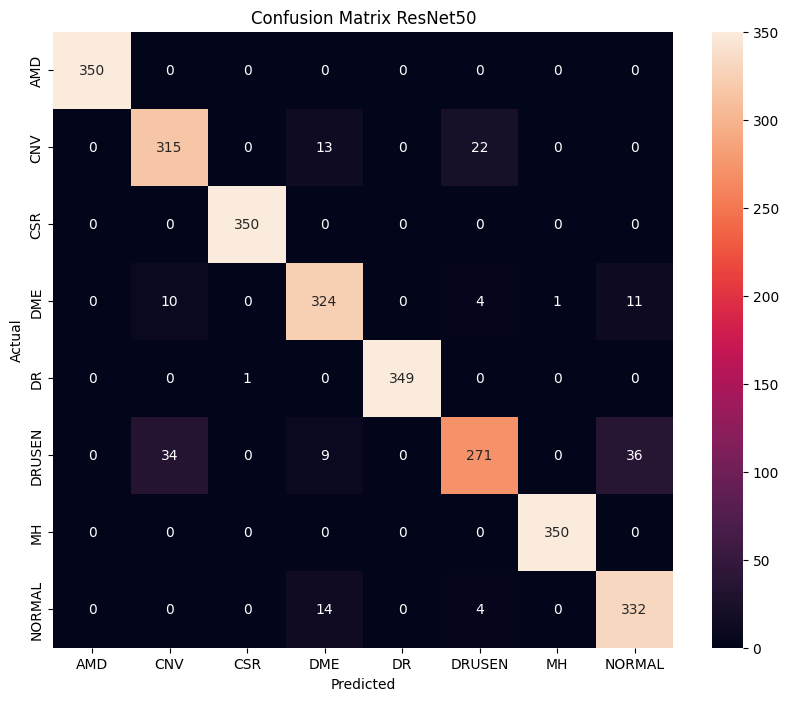

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix ResNet50")

plt.savefig("cm_resnet50.png")
plt.show()

In [56]:
import os
print([f for f in os.listdir() if f.endswith(".keras")])

['resnet50_retina.keras', 'efficientnetv2_retina.keras']


In [42]:
base_model = EfficientNetV2S(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [43]:
inputs = tf.keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

outputs = layers.Dense(
    8,
    activation="softmax"
)(x)

model_eff = Model(inputs, outputs)

In [44]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_eff.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,661,352 (78.82 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [45]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )
]

In [46]:
history_eff = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 149s 171ms/step - accuracy: 0.7991 - loss: 0.5335 - val_accuracy: 0.8793 - val_loss: 0.3248 - learning_rate: 0.0010
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 87s 121ms/step - accuracy: 0.8532 - loss: 0.3888 - val_accuracy: 0.8914 - val_loss: 0.2827 - learning_rate: 0.0010
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 69s 120ms/step - accuracy: 0.8651 - loss: 0.3493 - val_accuracy: 0.8904 - val_loss: 0.2811 - learning_rate: 0.0010
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 84s 123ms/step - accuracy: 0.8742 - loss: 0.3295 - val_accuracy: 0.8925 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 81s 121ms/step - accuracy: 0.8801 - loss: 0.3154 - val_accuracy: 0.8968 - val_loss: 0.2607 - learning_rate: 0.0010


In [47]:
loss, acc = model_eff.evaluate(test_ds)

print("EfficientNetV2 Test Accuracy:", acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.8979 - loss: 0.2603
EfficientNetV2 Test Accuracy: 0.897857129573822


In [48]:
model_eff.save("efficientnetv2_retina.keras")

In [53]:
model_eff.save("/content/drive/MyDrive/TA_Retina/efficientnetv2_baseline.keras")

In [57]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [58]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [59]:
history_eff_ft = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 169s 169ms/step - accuracy: 0.8716 - loss: 0.3469 - val_accuracy: 0.9146 - val_loss: 0.2325 - learning_rate: 1.0000e-05
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 82s 141ms/step - accuracy: 0.8951 - loss: 0.2829 - val_accuracy: 0.9207 - val_loss: 0.2107 - learning_rate: 1.0000e-05
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 81s 140ms/step - accuracy: 0.9041 - loss: 0.2618 - val_accuracy: 0.9257 - val_loss: 0.1994 - learning_rate: 1.0000e-05
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 81s 141ms/step - accuracy: 0.9100 - loss: 0.2458 - val_accuracy: 0.9289 - val_loss: 0.1935 - learning_rate: 1.0000e-05
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 80s 137ms/step - accuracy: 0.9153 - loss: 0.2280 - val_accuracy: 0.9311 - val_loss: 0.1818 - learning_rate: 1.0000e-05


In [60]:
loss, acc = model_eff.evaluate(test_ds)

print("EfficientNetV2 Fine-Tuning Accuracy:", acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.9346 - loss: 0.1891
EfficientNetV2 Fine-Tuning Accuracy: 0.9346428513526917


In [61]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model_eff.predict(images, verbose=0)

    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         AMD       0.99      1.00      1.00       350
         CNV       0.91      0.84      0.87       350
         CSR       0.99      1.00      1.00       350
         DME       0.93      0.86      0.89       350
          DR       1.00      0.99      0.99       350
      DRUSEN       0.83      0.83      0.83       350
          MH       1.00      1.00      1.00       350
      NORMAL       0.84      0.97      0.90       350

    accuracy                           0.93      2800
   macro avg       0.94      0.93      0.93      2800
weighted avg       0.94      0.93      0.93      2800



In [62]:
model_eff.save(
    "/content/drive/MyDrive/TA_Retina/efficientnetv2_finetune.keras"
)

In [63]:
model_eff.save("efficientnetv2_finetune.keras")

In [89]:
import gc
import tensorflow as tf

try:
    del model_dense
except:
    pass

try:
    del base_model
except:
    pass

gc.collect()
tf.keras.backend.clear_session()

In [90]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import layers, Model

In [91]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [92]:
inputs = tf.keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model_dense = Model(
    inputs,
    outputs
)

In [93]:
model_dense.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_dense.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,960 (27.85 MB)

 Trainable params: 264,456 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [94]:
history_dense = model_dense.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 120s 151ms/step - accuracy: 0.7518 - loss: 0.6549 - val_accuracy: 0.8468 - val_loss: 0.3911
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 62s 108ms/step - accuracy: 0.8118 - loss: 0.4853 - val_accuracy: 0.8596 - val_loss: 0.3522
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.8293 - loss: 0.4418 - val_accuracy: 0.8614 - val_loss: 0.3463
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 84s 111ms/step - accuracy: 0.8330 - loss: 0.4245 - val_accuracy: 0.8736 - val_loss: 0.3384
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 61s 107ms/step - accuracy: 0.8369 - loss: 0.4111 - val_accuracy: 0.8721 - val_loss: 0.3284


In [95]:
loss, acc = model_dense.evaluate(test_ds)

print("DenseNet121 Baseline Accuracy:", acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.8782 - loss: 0.3171
DenseNet121 Baseline Accuracy: 0.8782142996788025


In [96]:
model_dense.save(
    "/content/drive/MyDrive/TA_Retina/densenet121_baseline.keras"
)

In [98]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [99]:
model_dense.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [100]:
history_dense_ft = model_dense.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 136s 157ms/step - accuracy: 0.8132 - loss: 0.5147 - val_accuracy: 0.8900 - val_loss: 0.2863
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 70s 122ms/step - accuracy: 0.8557 - loss: 0.3798 - val_accuracy: 0.9011 - val_loss: 0.2599
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 67s 116ms/step - accuracy: 0.8701 - loss: 0.3400 - val_accuracy: 0.9086 - val_loss: 0.2434
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8813 - loss: 0.3116 - val_accuracy: 0.9136 - val_loss: 0.2297
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 81s 118ms/step - accuracy: 0.8907 - loss: 0.2884 - val_accuracy: 0.9179 - val_loss: 0.2195


In [101]:
loss, acc = model_dense.evaluate(test_ds)

print("DenseNet121 Fine-Tuning Accuracy:", acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.9168 - loss: 0.2183
DenseNet121 Fine-Tuning Accuracy: 0.916785717010498


In [103]:
model_dense.save(
    "/content/drive/MyDrive/TA_Retina/densenet121_finetune.keras"
)

In [104]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model_dense.predict(
        images,
        verbose=0
    )

    y_pred.extend(
        np.argmax(preds, axis=1)
    )

    y_true.extend(
        labels.numpy()
    )

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.89      0.83      0.86       350
         CSR       0.99      1.00      0.99       350
         DME       0.90      0.84      0.87       350
          DR       0.99      0.98      0.99       350
      DRUSEN       0.80      0.76      0.78       350
          MH       0.99      0.99      0.99       350
      NORMAL       0.79      0.93      0.85       350

    accuracy                           0.92      2800
   macro avg       0.92      0.92      0.92      2800
weighted avg       0.92      0.92      0.92      2800



In [107]:
import os

folder = "/content/drive/MyDrive/TA_Retina"

if os.path.exists(folder):
    print(os.listdir(folder))
else:
    print("Folder tidak ditemukan")

['efficientnetv2_baseline.keras', 'efficientnetv2_finetune.keras', 'densenet121_baseline.keras', 'densenet121_finetune.keras']


In [108]:
from tensorflow.keras.models import load_model

model_resnet = load_model("/content/resnet50_retina.keras")

print("Model ResNet berhasil dimuat")

Model ResNet berhasil dimuat


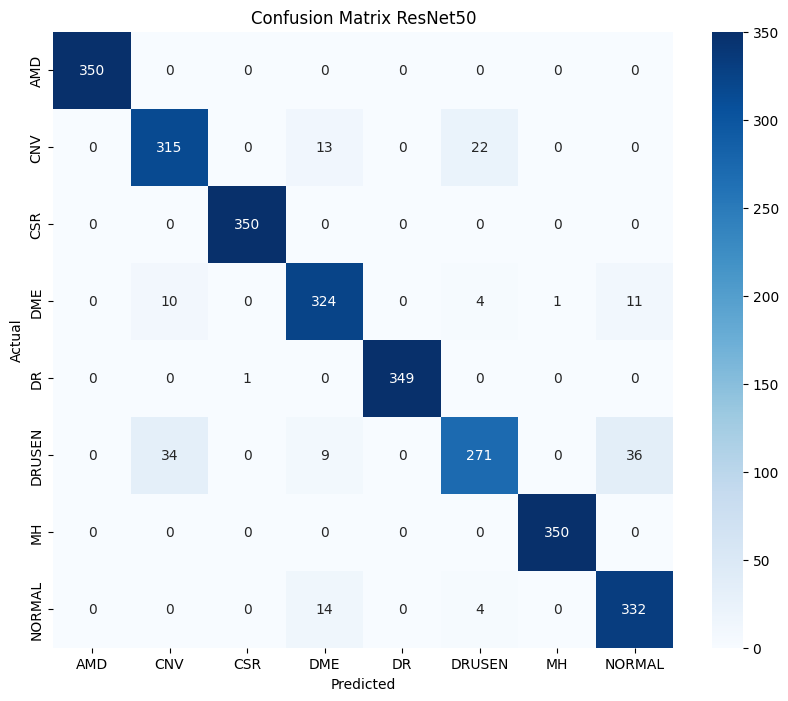

In [109]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model_resnet.predict(images, verbose=0)

    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix ResNet50")

plt.show()

In [110]:
import shutil

shutil.copy(
    "/content/resnet50_retina.keras",
    "/content/drive/MyDrive/TA_Retina/resnet50_retina.keras"
)

'/content/drive/MyDrive/TA_Retina/resnet50_retina.keras'

In [112]:
from tensorflow.keras.models import load_model

model_resnet = load_model("/content/resnet50_retina.keras")

loss, acc = model_resnet.evaluate(test_ds)

print("Accuracy:", acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.9432 - loss: 0.1914
Accuracy: 0.9432142972946167


In [113]:
for i, layer in enumerate(model_resnet.layers):
    print(i, layer.name)

0 input_layer_1
1 resnet50
2 global_average_pooling2d
3 dropout
4 dense
5 dense_1


In [114]:
for i, layer in enumerate(model_resnet.get_layer("resnet50").layers):
    print(i, layer.name)

0 input_layer
1 conv1_pad
2 conv1_conv
3 conv1_bn
4 conv1_relu
5 pool1_pad
6 pool1_pool
7 conv2_block1_1_conv
8 conv2_block1_1_bn
9 conv2_block1_1_relu
10 conv2_block1_2_conv
11 conv2_block1_2_bn
12 conv2_block1_2_relu
13 conv2_block1_0_conv
14 conv2_block1_3_conv
15 conv2_block1_0_bn
16 conv2_block1_3_bn
17 conv2_block1_add
18 conv2_block1_out
19 conv2_block2_1_conv
20 conv2_block2_1_bn
21 conv2_block2_1_relu
22 conv2_block2_2_conv
23 conv2_block2_2_bn
24 conv2_block2_2_relu
25 conv2_block2_3_conv
26 conv2_block2_3_bn
27 conv2_block2_add
28 conv2_block2_out
29 conv2_block3_1_conv
30 conv2_block3_1_bn
31 conv2_block3_1_relu
32 conv2_block3_2_conv
33 conv2_block3_2_bn
34 conv2_block3_2_relu
35 conv2_block3_3_conv
36 conv2_block3_3_bn
37 conv2_block3_add
38 conv2_block3_out
39 conv3_block1_1_conv
40 conv3_block1_1_bn
41 conv3_block1_1_relu
42 conv3_block1_2_conv
43 conv3_block1_2_bn
44 conv3_block1_2_relu
45 conv3_block1_0_conv
46 conv3_block1_3_conv
47 conv3_block1_0_bn
48 conv3_block1_

In [115]:
import os

test_dir = "/content/RetinalOCT_Dataset/RetinalOCT_Dataset/test"

for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)

    if os.path.isdir(cls_path):
        img_file = os.listdir(cls_path)[0]
        img_path = os.path.join(cls_path, img_file)

        print("Class :", cls)
        print("Path  :", img_path)
        break

Class : CNV
Path  : /content/RetinalOCT_Dataset/RetinalOCT_Dataset/test/CNV/cnv_test_1331.jpg


In [123]:
import shutil

files = [
    "resnet50_retina.keras",
    "efficientnetv2_finetune.keras",
    "densenet121_finetune.keras",
    "cm_resnet50.png",
    "resnet50_report.txt"
]

for f in files:
    try:
        shutil.copy(
            f,
            "/content/drive/MyDrive/TA_Retina/" + f
        )
        print("Copied:", f)
    except:
        print("Not found:", f)

Copied: resnet50_retina.keras
Copied: efficientnetv2_finetune.keras
Not found: densenet121_finetune.keras
Copied: cm_resnet50.png
Copied: resnet50_report.txt


In [124]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_PATH = "/content/RetinalOCT_Dataset/RetinalOCT_Dataset/test/CNV/cnv_test_1331.jpg"

# Load gambar
img = tf.keras.preprocessing.image.load_img(
    IMG_PATH,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Ambil layer-layer classifier
resnet_base = model_resnet.get_layer("resnet50")
gap_layer = model_resnet.get_layer("global_average_pooling2d")
dropout_layer = model_resnet.get_layer("dropout")
dense_layer = model_resnet.get_layer("dense")
output_layer = model_resnet.get_layer("dense_1")

with tf.GradientTape() as tape:

    conv_outputs = resnet_base(img_array)

    tape.watch(conv_outputs)

    x = gap_layer(conv_outputs)
    x = dropout_layer(x, training=False)
    x = dense_layer(x)

    predictions = output_layer(x)

    pred_index = tf.argmax(predictions[0])

    class_channel = predictions[:, pred_index]

grads = tape.gradient(
    class_channel,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)

heatmap /= tf.reduce_max(heatmap)

heatmap = heatmap.numpy()

print("Predicted Class:", class_names[pred_index])

Predicted Class: CNV


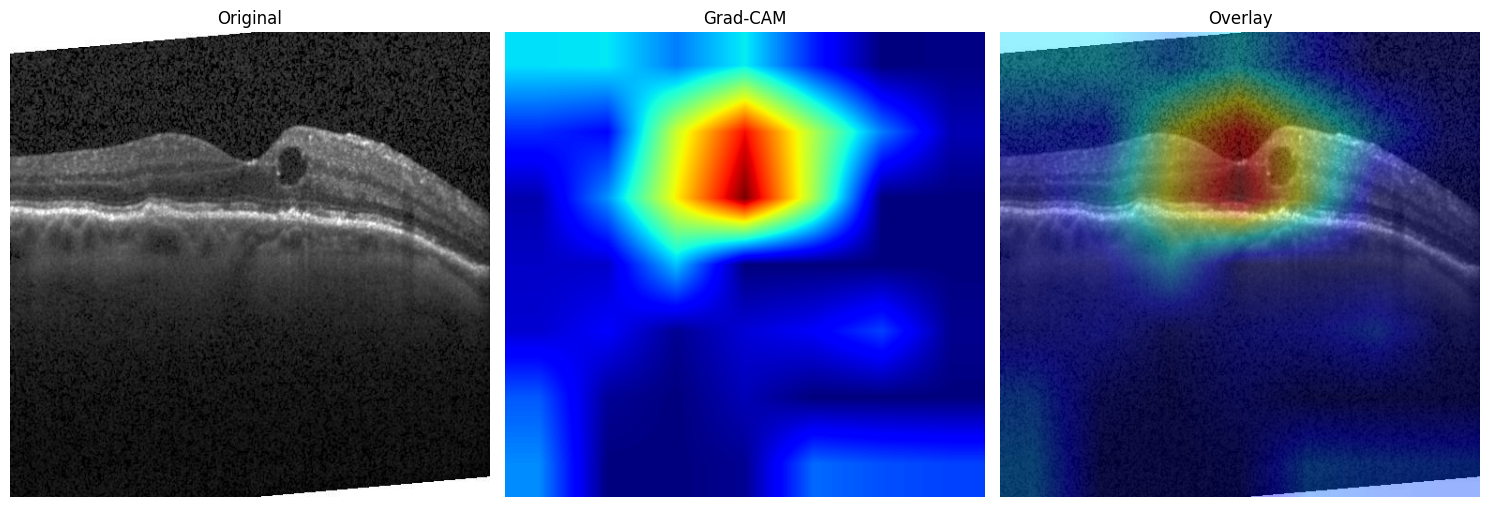

In [125]:
img_original = cv2.imread(IMG_PATH)
img_original = cv2.cvtColor(
    img_original,
    cv2.COLOR_BGR2RGB
)

heatmap_resized = cv2.resize(
    heatmap,
    (img_original.shape[1], img_original.shape[0])
)

heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

superimposed = cv2.addWeighted(
    img_original,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(superimposed)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [126]:
plt.savefig(
    "/content/drive/MyDrive/TA_Retina/gradcam_resnet50_cnv.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>